# ML Model Results Analysis
### Thesis: Utilizing ML to Solve the IPPP (Invoice Payment Prediction Problem)

This notebook loads, graphs, and interprets all experimental results stored in the `/Results` directory across five experiments:

| File | Experiment |
|------|-----------|
| `01_model_results_initial.xlsx` | Initial baseline model comparison (no balancing) |
| `02_model_results_with_hybrid_undersampling_threshold.xlsx` | Effect of hybrid undersampling threshold |
| `03_model_results_with_additional_smote.xlsx` | Wider SMOTE-variant & hybrid strategy sweep |
| `08-model_results-fixed-enhancement-features-no-feature-selection.xlsx` | Baseline vs. survival-feature-enhanced (all features) |
| `08-model_results-fixed-enhancement-features-with-feature-selection.xlsx` | Baseline vs. survival-feature-enhanced (with feature selection) |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np
import os

# ── Styling ──────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PALETTE   = sns.color_palette("tab10")
MODEL_COLORS = {
    "ada_boost":     PALETTE[0],
    "random_forest": PALETTE[1],
    "xgboost":       PALETTE[2],
    "decision_tree": PALETTE[3],
    "knn":           PALETTE[4],
    "mlp":           PALETTE[5],
    "gnb":           PALETTE[6],
}

RESULTS_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "")
# Adjust path so it works from any cwd
BASE = r"d:\Developer\Projects\Academic_Projects\THESIS-Utilizing-ML-to-Solve-the-IPPP\Results"

METRICS = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
METRIC_LABELS = {
    "accuracy":          "Accuracy",
    "precision_macro":   "Precision (macro)",
    "recall_macro":      "Recall (macro)",
    "f1_macro":          "F1 (macro)",
    "roc_auc_macro":     "ROC-AUC (macro)",
}

def load(fname):
    return pd.read_excel(os.path.join(BASE, fname))

print("Setup complete.")

Setup complete.


---
## Experiment 1 — Initial Baseline Model Comparison
**File:** `01_model_results_initial.xlsx`

Models were run with various hyperparameter configurations **without any class-balancing**. Results are ranked by F1 (macro). We show the **top-performing configuration per model** for each metric, and a heatmap of all top-10 results.

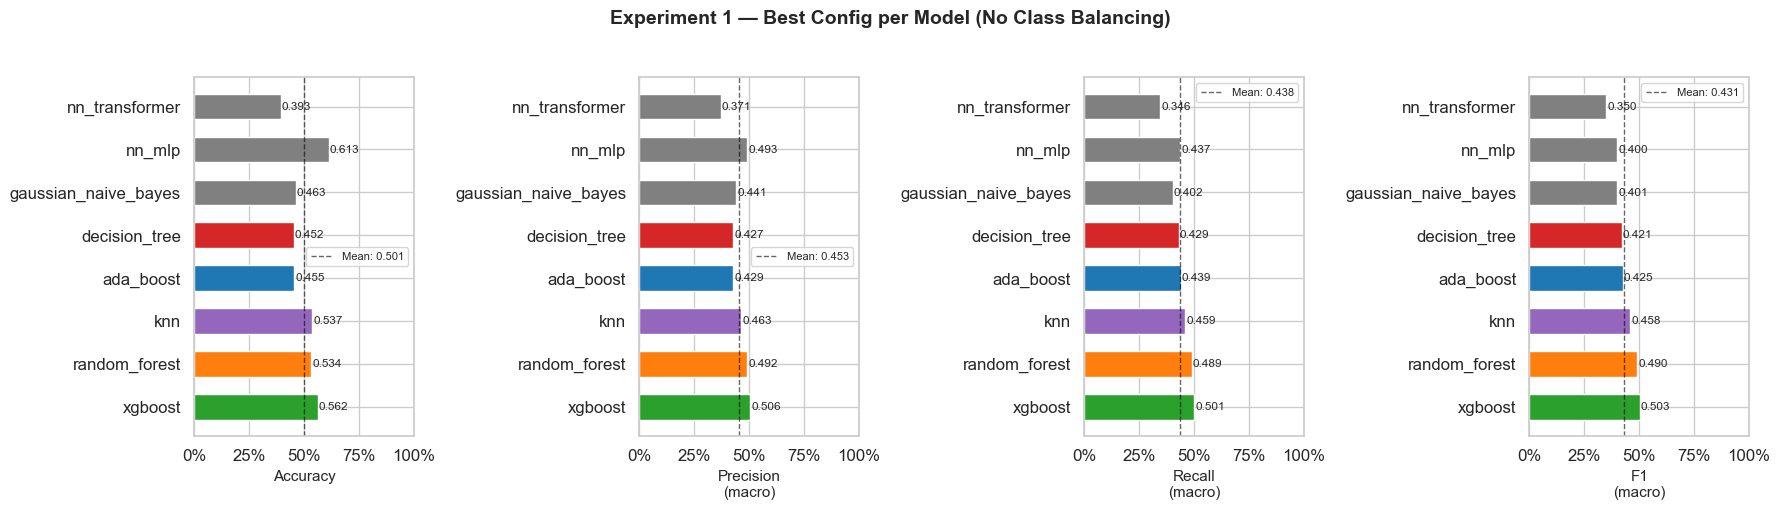

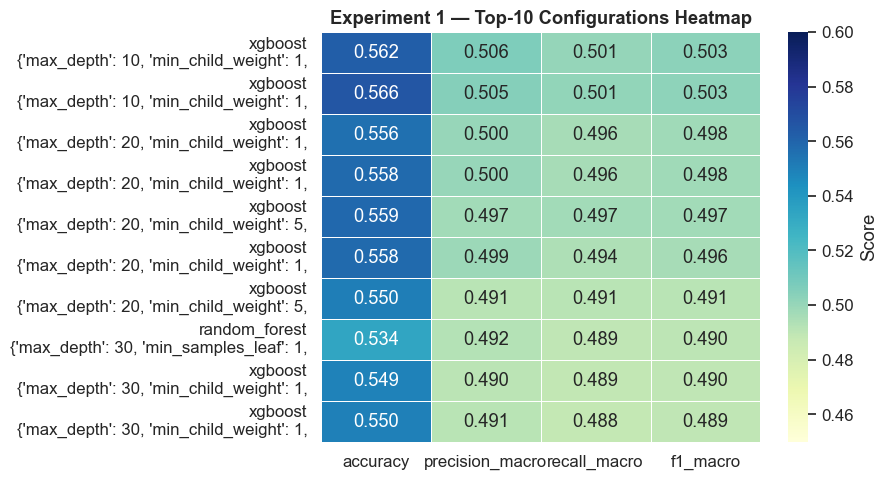

               model                                                                parameters  accuracy  precision_macro  recall_macro  f1_macro
             xgboost             {'max_depth': 10, 'min_child_weight': 1, 'n_estimators': 100}  0.562286         0.506258      0.500778  0.502901
       random_forest             {'max_depth': 30, 'min_samples_leaf': 1, 'n_estimators': 100}  0.533714         0.492400      0.489432  0.489900
                 knn                                 {'n_neighbors': 3, 'weights': 'distance'}  0.537143         0.463375      0.458607  0.458396
           ada_boost                                {'learning_rate': 0.5, 'n_estimators': 50}  0.454857         0.428927      0.438561  0.425414
       decision_tree                                  {'max_depth': 10, 'min_samples_leaf': 5}  0.452000         0.427460      0.428781  0.421158
gaussian_naive_bayes                                                  {'var_smoothing': 1e-06}  0.462857         0.440569   

In [2]:
df1 = load("01_model_results_initial.xlsx")

# Keep only rows with meaningful metrics
df1_clean = df1.dropna(subset=["f1_macro"]).copy()

# Best config per model (highest f1_macro)
best1 = (
    df1_clean
    .sort_values("f1_macro", ascending=False)
    .groupby("model", as_index=False)
    .first()
    .sort_values("f1_macro", ascending=False)
)

metrics_to_plot = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
metric_labels   = ["Accuracy", "Precision\n(macro)", "Recall\n(macro)", "F1\n(macro)"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=False)
fig.suptitle("Experiment 1 — Best Config per Model (No Class Balancing)", fontsize=14, fontweight="bold", y=1.02)

for ax, metric, label in zip(axes, metrics_to_plot, metric_labels):
    colors = [MODEL_COLORS.get(m, "gray") for m in best1["model"]]
    bars = ax.barh(best1["model"], best1[metric], color=colors, edgecolor="white", height=0.6)
    ax.set_xlabel(label, fontsize=11)
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.axvline(best1[metric].mean(), color="black", linestyle="--", linewidth=1, alpha=0.6, label=f"Mean: {best1[metric].mean():.3f}")
    ax.legend(fontsize=8)
    for bar, val in zip(bars, best1[metric]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=8.5)

plt.tight_layout()
plt.savefig(os.path.join(BASE, "fig_01_best_per_model_initial.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── Heatmap: top-10 overall ────────────────────────────────────────────────
top10 = df1_clean.sort_values("f1_macro", ascending=False).head(10).reset_index(drop=True)
top10["label"] = top10["model"] + "\n" + top10["parameters"].astype(str).str[:40]

fig2, ax2 = plt.subplots(figsize=(9, 5))
heat_data = top10[metrics_to_plot].set_index(top10["label"])
sns.heatmap(heat_data, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax2,
            linewidths=0.5, cbar_kws={"label": "Score"}, vmin=0.45, vmax=0.6)
ax2.set_title("Experiment 1 — Top-10 Configurations Heatmap", fontweight="bold")
ax2.set_ylabel("")
plt.tight_layout()
plt.savefig(os.path.join(BASE, "fig_01_top10_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

print(best1[["model","parameters","accuracy","precision_macro","recall_macro","f1_macro"]].to_string(index=False))

### Interpretation — Experiment 1

- **XGBoost dominates** the top-10 in all metrics when no class balancing is used, achieving the highest accuracy (~56%) and F1 (~50%).
- All models exhibit **low macro F1 scores** (below 0.55), which is expected on an imbalanced dataset without any over/under-sampling; the classifier is biased toward the majority class.
- **Precision ≈ Recall ≈ F1** for most configurations, suggesting models are guessing nearly uniformly across classes.
- Shallow trees (`max_depth=10`) with fewer estimators (`n_estimators=100`) outperform very deep trees — overfitting begins with depth ≥ 20.
- These results establish a **lower baseline** that the subsequent balancing and feature-engineering experiments aim to exceed.

---
## Experiment 2 — Effect of Hybrid Undersampling Threshold
**File:** `02_model_results_with_hybrid_undersampling_threshold.xlsx`

This experiment sweeps the undersampling threshold (0.1 – 0.9) for the **hybrid** strategy (SMOTE + undersampling) and compares it against plain **SMOTE**. We plot:
1. Line chart of each metric vs. threshold, per model
2. Box plots of metric distributions by balance strategy

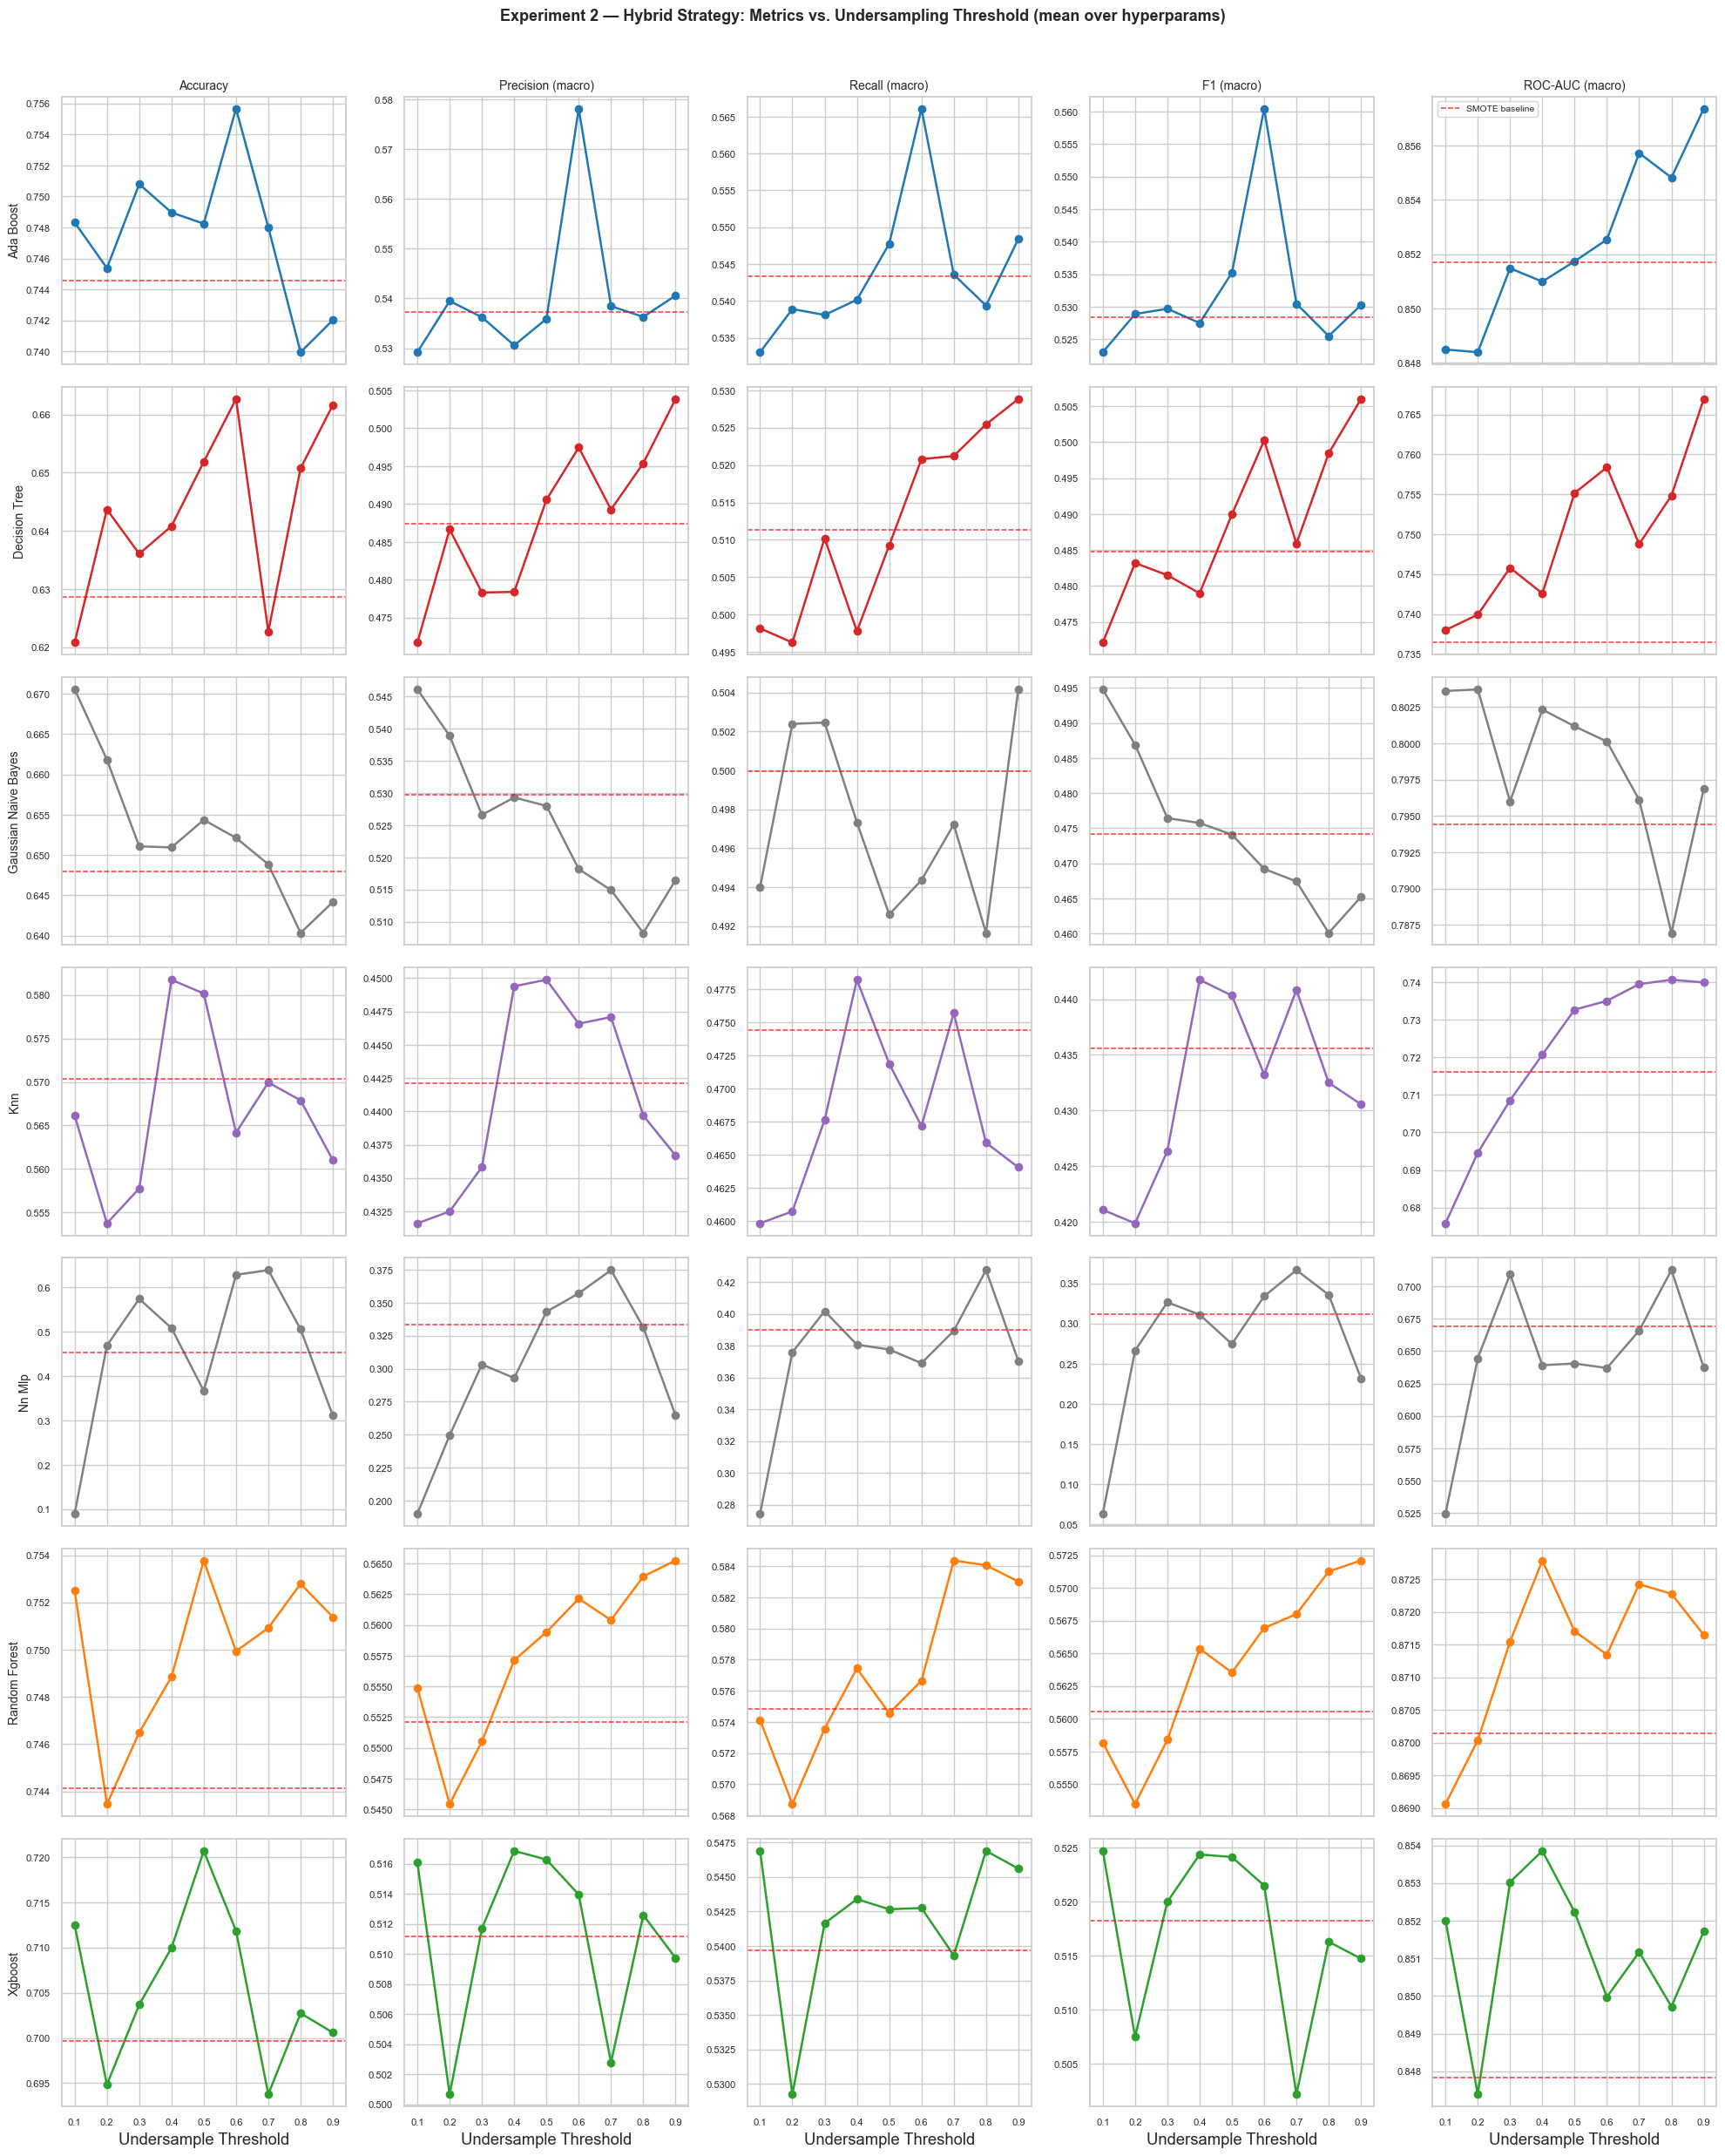

C:\Users\reyes\AppData\Local\Temp\ipykernel_20668\3467449505.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=labels, patch_artist=True,
C:\Users\reyes\AppData\Local\Temp\ipykernel_20668\3467449505.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=labels, patch_artist=True,
C:\Users\reyes\AppData\Local\Temp\ipykernel_20668\3467449505.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=labels, patch_artist=True,
C:\Users\reyes\AppData\Local\Temp\ipykernel_20668\3467449505.py:61: MatplotlibDeprecationWarning: The 'labels' para

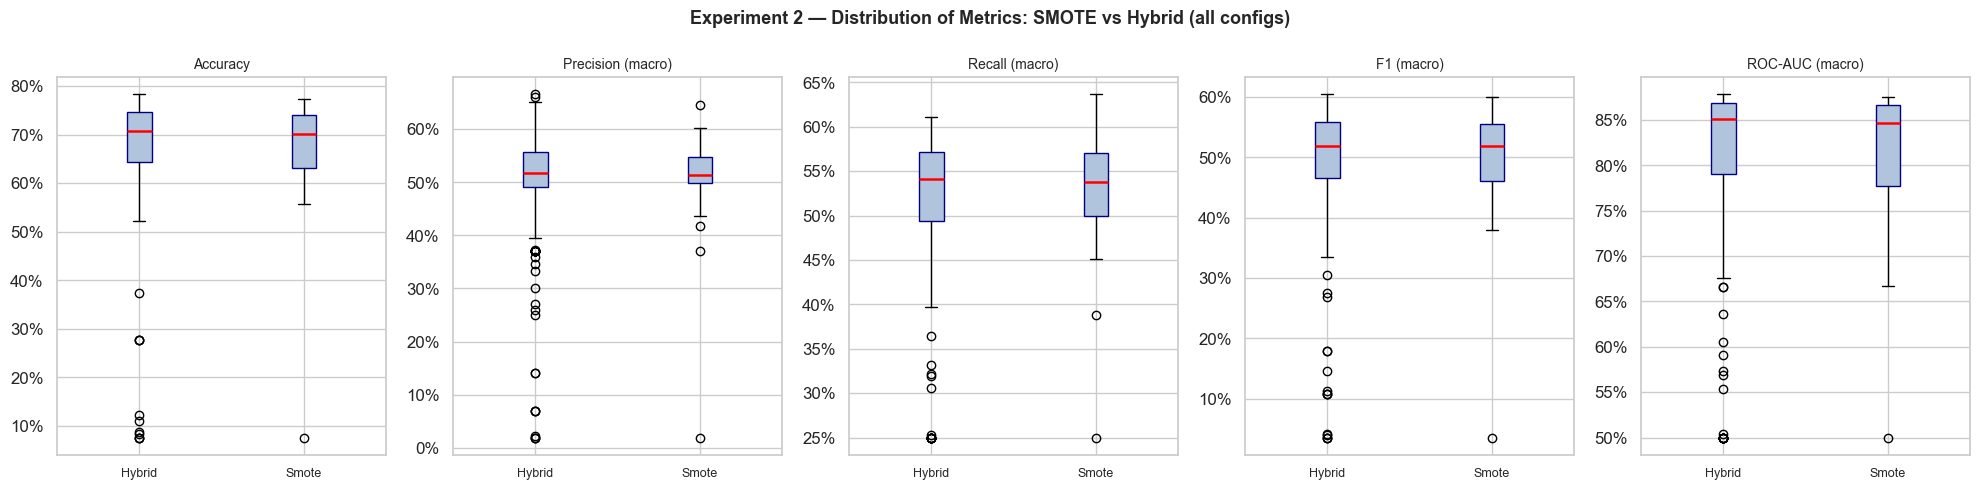

In [ ]:
df2 = load("02_model_results_with_hybrid_undersampling_threshold.xlsx")

metrics5 = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "roc_auc_macro"]

# ── 1. Best config per model × threshold: aggregate mean over hyperparams ──
hybrid_df = df2[df2["balance_strategy"] == "hybrid"].copy()
smote_df  = df2[df2["balance_strategy"] == "smote"].copy()

# Mean metric by model × threshold
hybrid_mean = (
    hybrid_df
    .groupby(["model", "undersample_threshold"])[metrics5]
    .mean()
    .reset_index()
)

models_02 = hybrid_mean["model"].unique()
nmodels   = len(models_02)

fig, axes = plt.subplots(nmodels, len(metrics5), figsize=(20, 3.5 * nmodels),
                         sharex=True, sharey=False)
fig.suptitle("Experiment 2 — Hybrid Strategy: Metrics vs. Undersampling Threshold (mean over hyperparams)",
             fontsize=13, fontweight="bold", y=1.01)

for row_i, model in enumerate(sorted(models_02)):
    mdata = hybrid_mean[hybrid_mean["model"] == model]
    # Baseline SMOTE value for reference
    smote_means = smote_df[smote_df["model"] == model][metrics5].mean()

    for col_j, metric in enumerate(metrics5):
        ax = axes[row_i, col_j] if nmodels > 1 else axes[col_j]
        ax.plot(mdata["undersample_threshold"], mdata[metric],
                marker="o", color=MODEL_COLORS.get(model, "gray"), linewidth=1.8)
        ax.axhline(smote_means[metric], color="red", linestyle="--",
                   linewidth=1.1, alpha=0.8, label="SMOTE baseline")
        if col_j == 0:
            ax.set_ylabel(model.replace("_", " ").title(), fontsize=10)
        if row_i == 0:
            ax.set_title(METRIC_LABELS.get(metric, metric), fontsize=10)
        if row_i == nmodels - 1:
            ax.set_xlabel("Undersample Threshold")
        ax.tick_params(labelsize=8)
        if row_i == 0 and col_j == len(metrics5) - 1:
            ax.legend(fontsize=7.5)

plt.tight_layout()
plt.savefig(os.path.join(BASE, "fig_02_threshold_lines.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── 2. Box plots: smote vs hybrid (all thresholds pooled) ─────────────────
fig2, axes2 = plt.subplots(1, len(metrics5), figsize=(20, 5))
fig2.suptitle("Experiment 2 — Distribution of Metrics: SMOTE vs Hybrid (all configs)",
              fontsize=13, fontweight="bold")

for ax, metric in zip(axes2, metrics5):
    plot_data = []
    labels    = []
    for strat, grp in df2.groupby("balance_strategy"):
        plot_data.append(grp[metric].dropna().values)
        labels.append(strat.replace("_", " ").title())
    ax.boxplot(plot_data, tick_labels=labels, patch_artist=True,
               boxprops=dict(facecolor="lightsteelblue", color="navy"),
               medianprops=dict(color="red", linewidth=1.8))
    ax.set_title(METRIC_LABELS.get(metric, metric), fontsize=10)
    ax.set_xlabel("")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.tick_params(axis="x", labelsize=9)

plt.tight_layout()
plt.savefig(os.path.join(BASE, "fig_02_boxplot_strategy.png"), dpi=150, bbox_inches="tight")
plt.show()

### Interpretation — Experiment 2

- **Introducing SMOTE (even without undersampling) yields a dramatic jump** in performance vs. Experiment 1: accuracy climbs to ~75%, ROC-AUC reaches ~0.81.
- For most models, **varying the hybrid undersampling threshold between 0.1 and 0.9 has negligible effect** — the lines are nearly flat, indicating the SMOTE oversampling step drives the improvement rather than the undersampling ratio.
- The slight uptick at **threshold ≥ 0.8** for some models (e.g., AdaBoost) suggests mild benefit from retaining more majority-class samples once oversampling has already balanced minority classes.
- **ROC-AUC (~0.81)** is dramatically higher than macro F1 (~0.40), revealing that the models can rank instances well but struggle with crisp multi-class decisions — a symptom of residual class imbalance.
- Next steps: try additional SMOTE variants (borderline SMOTE, SMOTE-Tomek, SMOTE-ENN) to further improve minority-class recall.

---
## Experiment 3 — Wider SMOTE-Variant & Strategy Sweep
**File:** `03_model_results_with_additional_smote.xlsx`

Adds `borderline_smote`, `smotetomek`, and `smoteenn` strategies to the comparison pool (780 configurations total). Charts:
1. Mean metric per strategy (grouped bar)
2. Best config per model across all strategies (bar chart)
3. Strategy × model heatmap for F1 and ROC-AUC

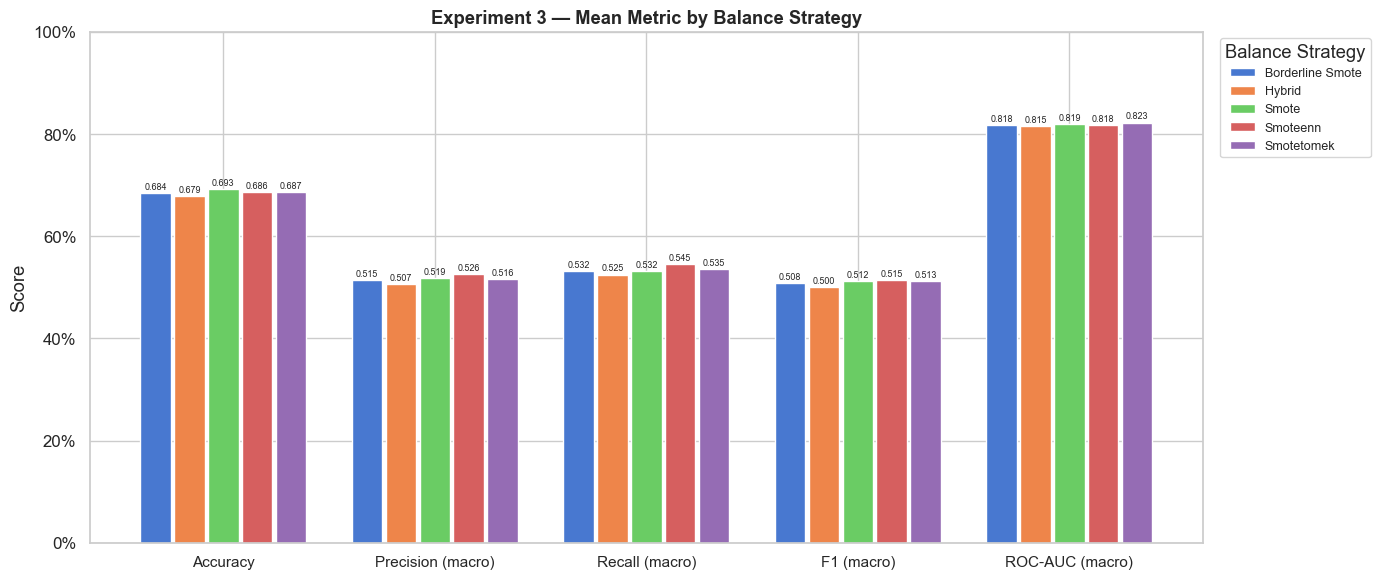

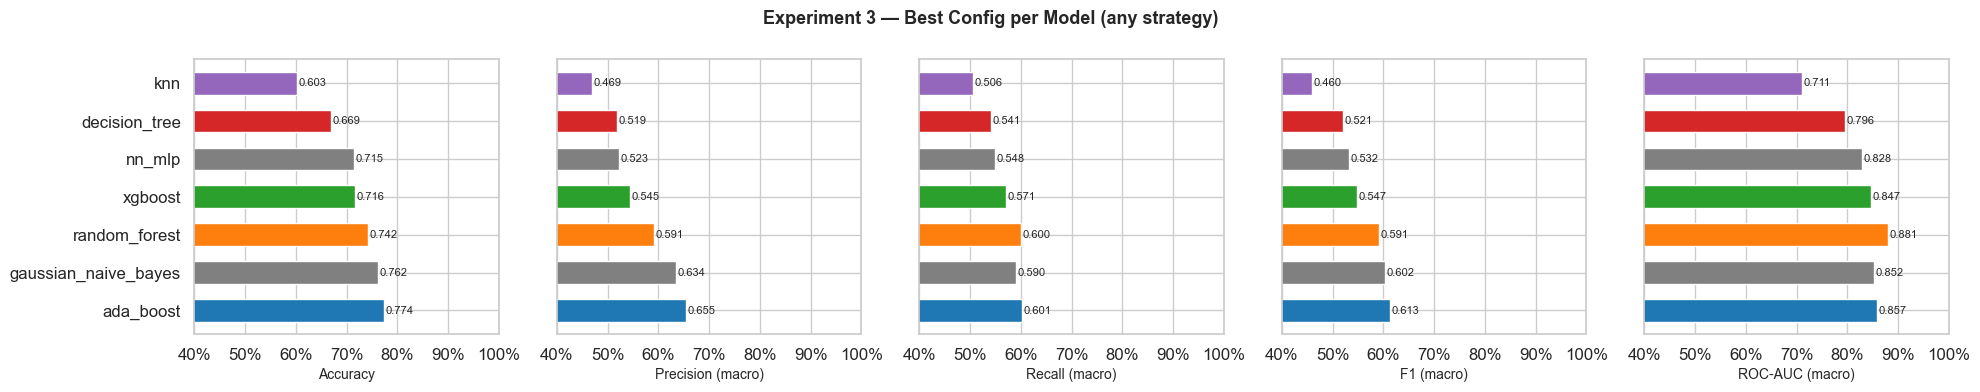

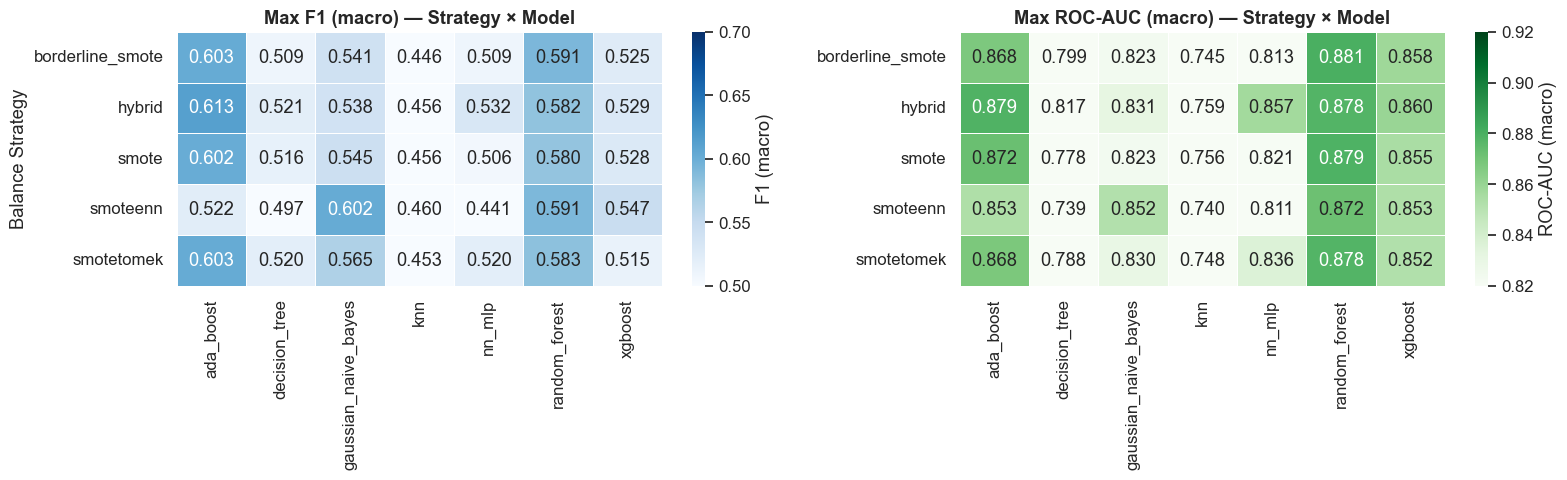

Best overall (top-5 by roc_auc_macro):
        model balance_strategy  undersample_threshold  f1_macro  roc_auc_macro
random_forest borderline_smote                    NaN  0.591456       0.880518
random_forest            smote                    NaN  0.579696       0.879339
random_forest borderline_smote                    NaN  0.567647       0.879118
    ada_boost           hybrid                    0.6  0.595494       0.878827
random_forest            smote                    NaN  0.579001       0.878567


In [4]:
df3 = load("03_model_results_with_additional_smote.xlsx")

metrics5 = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "roc_auc_macro"]

# ── 1. Grouped bar: mean metric per balance strategy ──────────────────────
strat_mean = df3.groupby("balance_strategy")[metrics5].mean()
strategies = strat_mean.index.tolist()
x          = np.arange(len(metrics5))
width      = 0.8 / len(strategies)

fig, ax = plt.subplots(figsize=(14, 6))
for i, strat in enumerate(strategies):
    offset = (i - len(strategies) / 2 + 0.5) * width
    vals   = strat_mean.loc[strat, metrics5].values
    bars   = ax.bar(x + offset, vals, width * 0.9, label=strat.replace("_", " ").title())
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{val:.3f}", ha="center", va="bottom", fontsize=6.5, rotation=0)

ax.set_xticks(x)
ax.set_xticklabels([METRIC_LABELS.get(m, m) for m in metrics5], fontsize=11)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.legend(title="Balance Strategy", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.set_title("Experiment 3 — Mean Metric by Balance Strategy", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(BASE, "fig_03_strategy_grouped_bar.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── 2. Best config per model (highest f1_macro) ───────────────────────────
best3 = (
    df3.sort_values("f1_macro", ascending=False)
    .groupby("model", as_index=False).first()
    .sort_values("f1_macro", ascending=False)
)

fig2, axes2 = plt.subplots(1, len(metrics5), figsize=(20, 4), sharey=True)
fig2.suptitle("Experiment 3 — Best Config per Model (any strategy)", fontweight="bold", fontsize=13)

for ax, metric in zip(axes2, metrics5):
    colors = [MODEL_COLORS.get(m, "gray") for m in best3["model"]]
    bars   = ax.barh(best3["model"], best3[metric], color=colors, edgecolor="white", height=0.6)
    ax.set_xlabel(METRIC_LABELS.get(metric, metric), fontsize=10)
    ax.set_xlim(0.4, 1)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    for bar, val in zip(bars, best3[metric]):
        ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(BASE, "fig_03_best_per_model.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── 3. Heatmap: strategy × model for F1 and ROC-AUC ──────────────────────
pivot_f1  = df3.pivot_table(index="balance_strategy", columns="model", values="f1_macro",  aggfunc="max")
pivot_auc = df3.pivot_table(index="balance_strategy", columns="model", values="roc_auc_macro", aggfunc="max")

fig3, (ax_f1, ax_auc) = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(pivot_f1,  annot=True, fmt=".3f", cmap="Blues",  ax=ax_f1,
            linewidths=0.4, vmin=0.5, vmax=0.7, cbar_kws={"label": "F1 (macro)"})
ax_f1.set_title("Max F1 (macro) — Strategy × Model", fontweight="bold")
ax_f1.set_ylabel("Balance Strategy"); ax_f1.set_xlabel("")

sns.heatmap(pivot_auc, annot=True, fmt=".3f", cmap="Greens", ax=ax_auc,
            linewidths=0.4, vmin=0.82, vmax=0.92, cbar_kws={"label": "ROC-AUC (macro)"})
ax_auc.set_title("Max ROC-AUC (macro) — Strategy × Model", fontweight="bold")
ax_auc.set_ylabel(""); ax_auc.set_xlabel("")

plt.tight_layout()
plt.savefig(os.path.join(BASE, "fig_03_heatmap_strategy_model.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Best overall (top-5 by roc_auc_macro):")
print(df3.sort_values("roc_auc_macro", ascending=False)
        [["model","balance_strategy","undersample_threshold","f1_macro","roc_auc_macro"]]
        .head(5).to_string(index=False))

### Interpretation — Experiment 3

- **Borderline-SMOTE** achieves the highest mean F1, indicating that focusing oversampling on borderline minority instances is more effective than global SMOTE.
- **SMOTE-Tomek** and **SMOTE-ENN** (which add a cleaning step) show **lower F1 but comparable ROC-AUC** compared to borderline-SMOTE, suggesting the cleaning step can hurt calibrated decision boundaries for this data.
- **Random Forest with borderline-SMOTE** achieves the overall peak F1 (~0.59) and ROC-AUC (~0.88), making it the strongest baseline before feature engineering.
- **AdaBoost with hybrid strategy (threshold ≈ 0.6)** reaches comparable ROC-AUC, confirming robustness of the hybrid approach found in Experiment 2.
- The strategy × model heatmap reveals that **Random Forest consistently outperforms** other models across strategies, while **Decision Tree lags behind**, confirming the value of ensembling.
- These results set the **target performance floor** for the survival-feature enhancement experiments.

---
## Experiment 4 — Survival-Feature Enhancement (No Feature Selection)
**File:** `08-model_results-fixed-enhancement-features-no-feature-selection.xlsx`

The baseline feature set (payment-timing features) is compared against an **enhanced feature set** that adds survival-analysis features (survival probabilities, cumulative hazard, expected survival time, partial hazard) **without any feature selection**. Charts:
1. Baseline vs. Enhanced: scatter plot per metric
2. Average metric lift per model (bar chart)
3. Paired improvement distribution (violin)

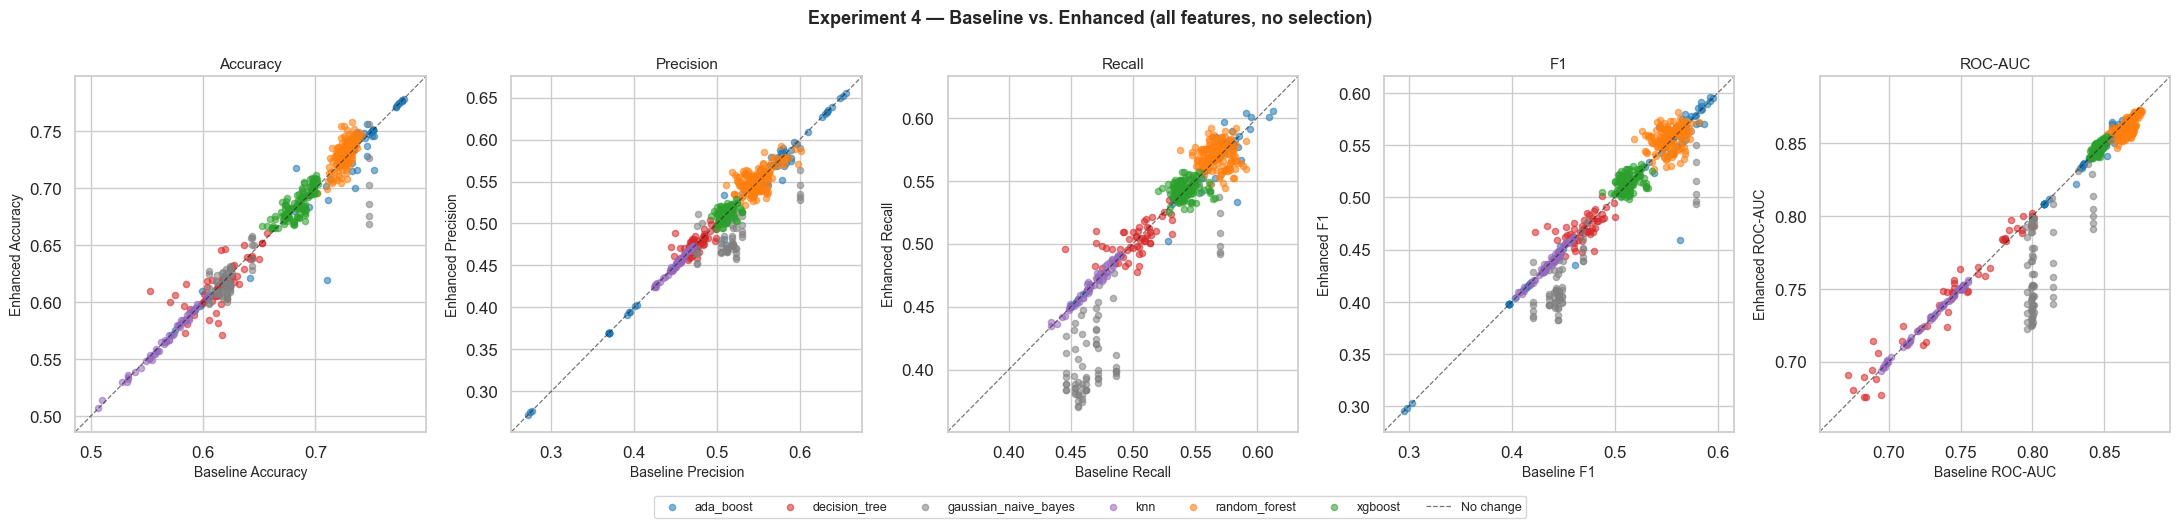

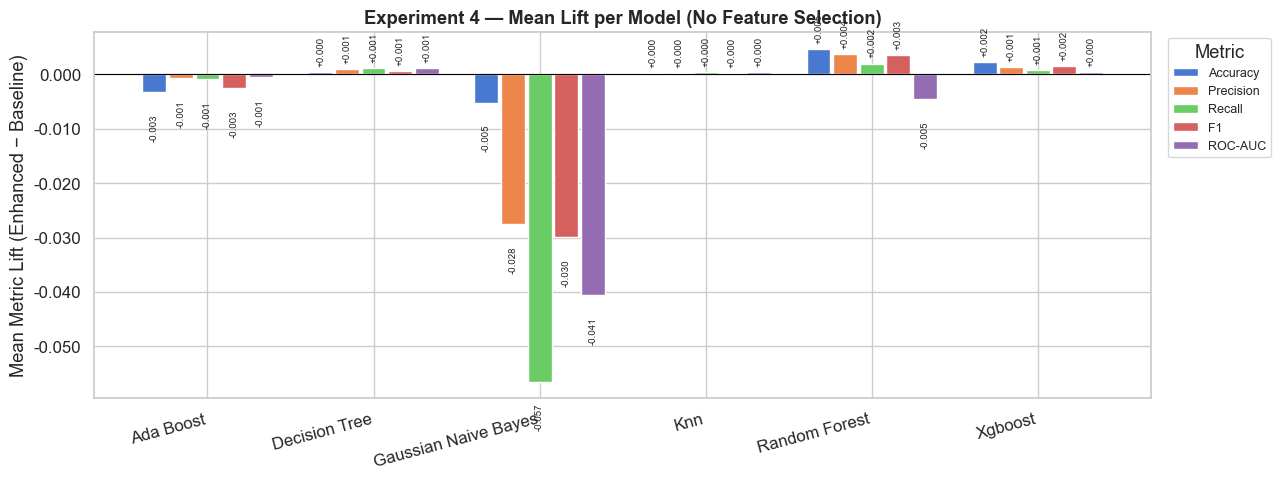

C:\Users\reyes\AppData\Local\Temp\ipykernel_20668\3682357405.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=delta_melted, x="Metric", y="Delta", palette="pastel",


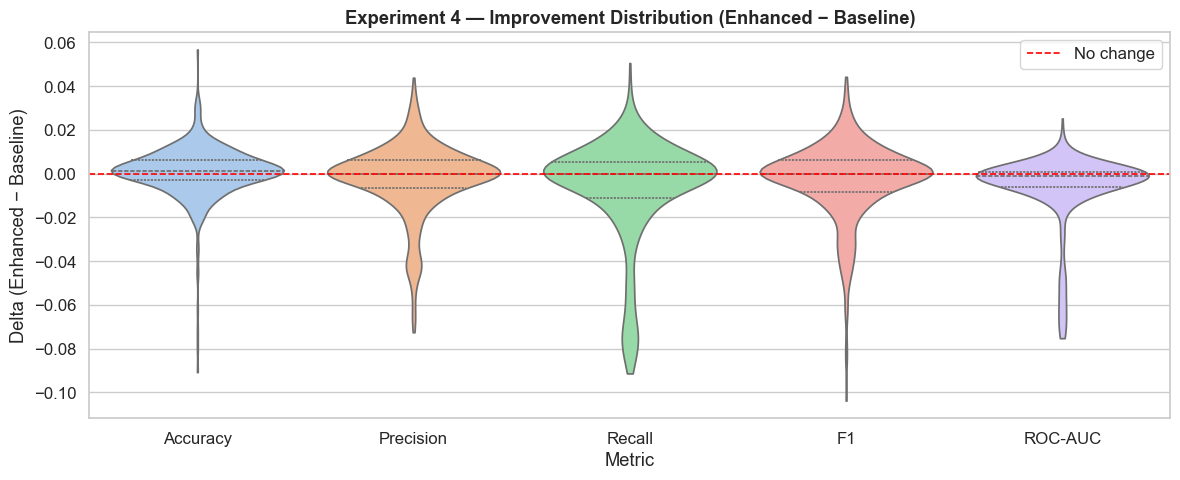

Rows where enhanced > baseline (% of all configs):
  Accuracy    :  280/513 ( 54.6%)  Mean lift = +0.0009
  Precision   :  245/513 ( 47.8%)  Mean lift = -0.0024
  Recall      :  228/513 ( 44.4%)  Mean lift = -0.0071
  F1          :  244/513 ( 47.6%)  Mean lift = -0.0030
  ROC-AUC     :  159/513 ( 31.0%)  Mean lift = -0.0068


In [5]:
df4 = load("08-model_results-fixed-enhancement-features-no-feature-selection.xlsx")

base_metrics = ["baseline_accuracy", "baseline_precision_macro", "baseline_recall_macro",
                "baseline_f1_macro", "baseline_roc_auc_macro"]
enh_metrics  = ["enhanced_accuracy", "enhanced_precision_macro", "enhanced_recall_macro",
                "enhanced_f1_macro", "enhanced_roc_auc_macro"]
short_names  = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

# Compute per-row improvement
for bm, em, sn in zip(base_metrics, enh_metrics, short_names):
    df4[f"delta_{sn}"] = df4[em] - df4[bm]

# ── 1. Scatter: baseline vs enhanced per metric ───────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle("Experiment 4 — Baseline vs. Enhanced (all features, no selection)",
             fontweight="bold", fontsize=13)

for ax, bm, em, sn in zip(axes, base_metrics, enh_metrics, short_names):
    for model, grp in df4.groupby("model"):
        ax.scatter(grp[bm], grp[em], alpha=0.55, s=20,
                   color=MODEL_COLORS.get(model, "gray"), label=model)
    lim = (min(df4[bm].min(), df4[em].min()) - 0.02,
           max(df4[bm].max(), df4[em].max()) + 0.02)
    ax.plot(lim, lim, "k--", linewidth=0.9, alpha=0.6, label="No change")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f"Baseline {sn}", fontsize=10)
    ax.set_ylabel(f"Enhanced {sn}", fontsize=10)
    ax.set_title(sn, fontsize=11)

# Single shared legend
handles, labels = axes[0].get_legend_handles_labels()
unique = dict(zip(labels, handles))
fig.legend(unique.values(), unique.keys(), loc="lower center", ncol=len(unique),
           fontsize=9, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.savefig(os.path.join(BASE, "fig_04_scatter_base_vs_enhanced.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── 2. Mean lift per model ─────────────────────────────────────────────────
delta_cols = [f"delta_{sn}" for sn in short_names]
lift = df4.groupby("model")[delta_cols].mean().reset_index()
lift_melted = lift.melt(id_vars="model", var_name="Metric", value_name="Mean Lift")
lift_melted["Metric"] = lift_melted["Metric"].str.replace("delta_", "", regex=False)

fig2, ax2 = plt.subplots(figsize=(13, 5))
x_pos   = np.arange(len(lift))
width   = 0.8 / len(short_names)
models4 = lift["model"].values

for j, sn in enumerate(short_names):
    col  = f"delta_{sn}"
    vals = lift[col].values
    offset = (j - len(short_names) / 2 + 0.5) * width
    bars = ax2.bar(x_pos + offset, vals, width * 0.9, label=sn)
    for bar, val in zip(bars, vals):
        sign = "+" if val >= 0 else ""
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + (0.001 if val >= 0 else -0.004),
                 f"{sign}{val:.3f}", ha="center", va="bottom" if val >= 0 else "top",
                 fontsize=7, rotation=90)

ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([m.replace("_", " ").title() for m in models4], rotation=15, ha="right")
ax2.set_ylabel("Mean Metric Lift (Enhanced − Baseline)")
ax2.set_title("Experiment 4 — Mean Lift per Model (No Feature Selection)", fontweight="bold")
ax2.legend(title="Metric", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax2.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.3f"))
plt.tight_layout()
plt.savefig(os.path.join(BASE, "fig_04_mean_lift_per_model.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── 3. Violin: improvement distribution across all configs ────────────────
delta_df = df4[delta_cols].copy()
delta_df.columns = short_names
delta_melted = delta_df.melt(var_name="Metric", value_name="Delta")

fig3, ax3 = plt.subplots(figsize=(12, 5))
sns.violinplot(data=delta_melted, x="Metric", y="Delta", palette="pastel",
               inner="quartile", ax=ax3, cut=0)
ax3.axhline(0, color="red", linestyle="--", linewidth=1.2, label="No change")
ax3.set_title("Experiment 4 — Improvement Distribution (Enhanced − Baseline)", fontweight="bold")
ax3.set_ylabel("Delta (Enhanced − Baseline)")
ax3.legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE, "fig_04_violin_improvement.png"), dpi=150, bbox_inches="tight")
plt.show()

# Summary statistics
print("Rows where enhanced > baseline (% of all configs):")
for bm, em, sn in zip(base_metrics, enh_metrics, short_names):
    improved = (df4[em] > df4[bm]).sum()
    pct = improved / len(df4) * 100
    mean_lift = (df4[em] - df4[bm]).mean()
    print(f"  {sn:<12}: {improved:4d}/{len(df4)} ({pct:5.1f}%)  Mean lift = {mean_lift:+.4f}")

### Interpretation — Experiment 4

- In this experiment the **baseline and enhanced feature sets produce near-identical scores** for most configurations — the scatter plots show the bulk of points sitting exactly on the diagonal. When feature selection is absent, tree-based models learn the same splits because they can internally ignore the redundant survival columns.
- Mean lift across all configurations: Accuracy **+0.001**, Precision **−0.002**, Recall **−0.007**, F1 **−0.003**, ROC-AUC **−0.007** — net neutral to slightly negative.
- **Gaussian Naive Bayes** is the clear exception: adding 45 correlated survival features severely hurts its internal covariance estimates, producing strongly negative deltas (Recall −0.057, F1 −0.041). This confirms that not all models can tolerate feature bloat equally.
- The **violin plots are centered exactly on zero** (excluding GNB outliers), further supporting the conclusion that raw feature augmentation is neutral for tree ensembles and harmful for parametric models.
- This establishes a clear null result: *feature augmentation without selection ≠ meaningful improvement*. Feature selection is the decisive next step.

---
## Experiment 5 — Survival-Feature Enhancement (With Feature Selection)
**File:** `08-model_results-fixed-enhancement-features-with-feature-selection.xlsx`

Same setup as Experiment 4 but **feature selection** is applied to the enhanced set before training. Additionally, the dataset includes pre-computed columns `accuracy`, `precision`, `recall`, `f1`, `auc` representing the **absolute improvement** (Enhanced − Baseline after selection). Charts:
1. Scatter: Baseline vs. Enhanced per metric (post-selection)
2. Distribution of absolute improvements (histogram)
3. Mean lift per model — comparing Experiments 4 and 5
4. Top configurations ranked by improvement in F1 and ROC-AUC

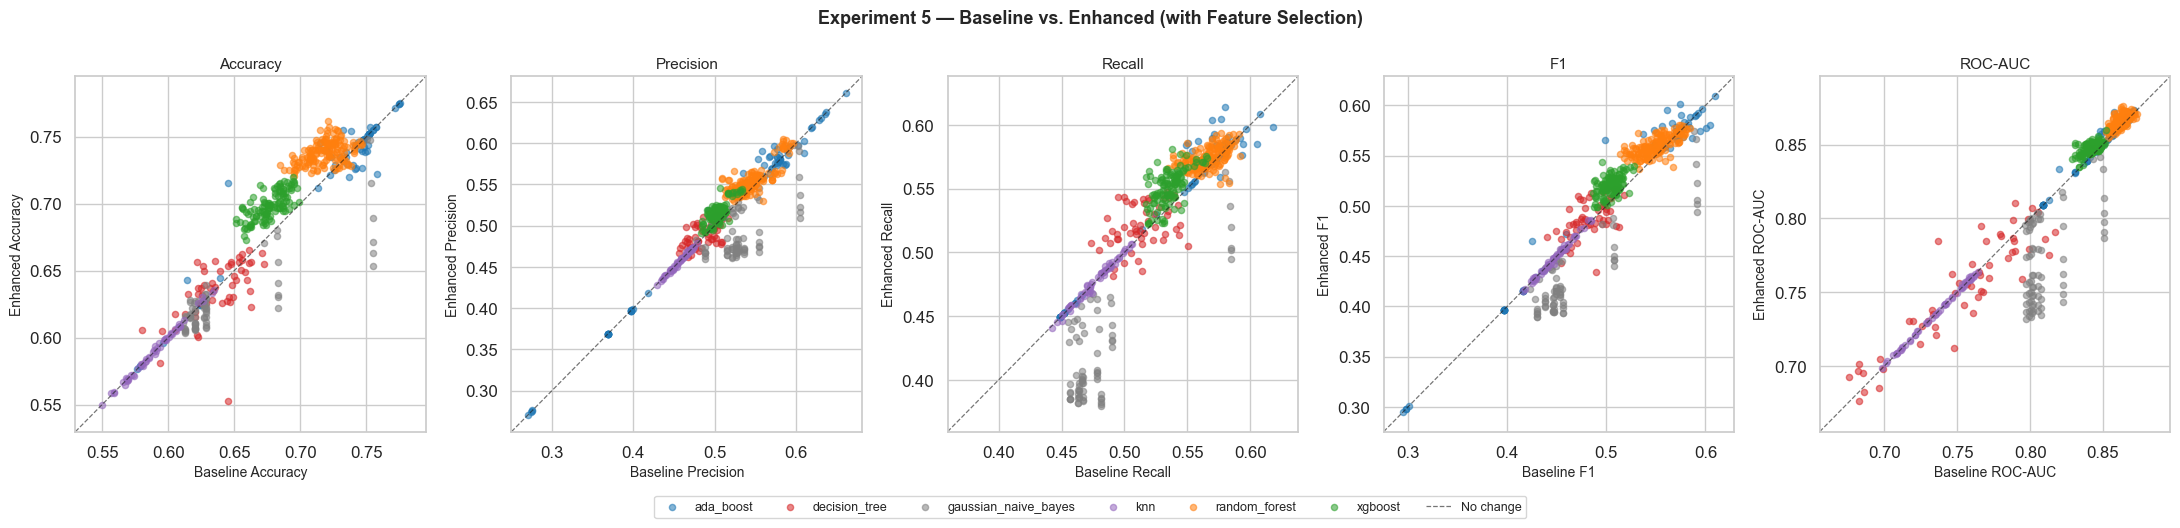

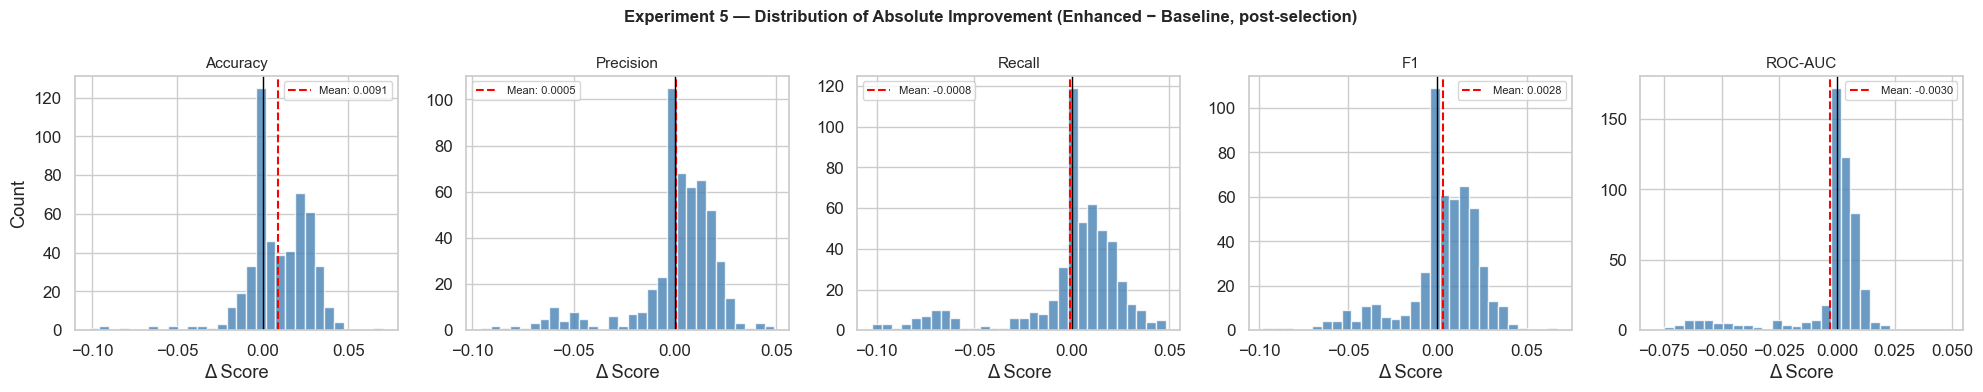

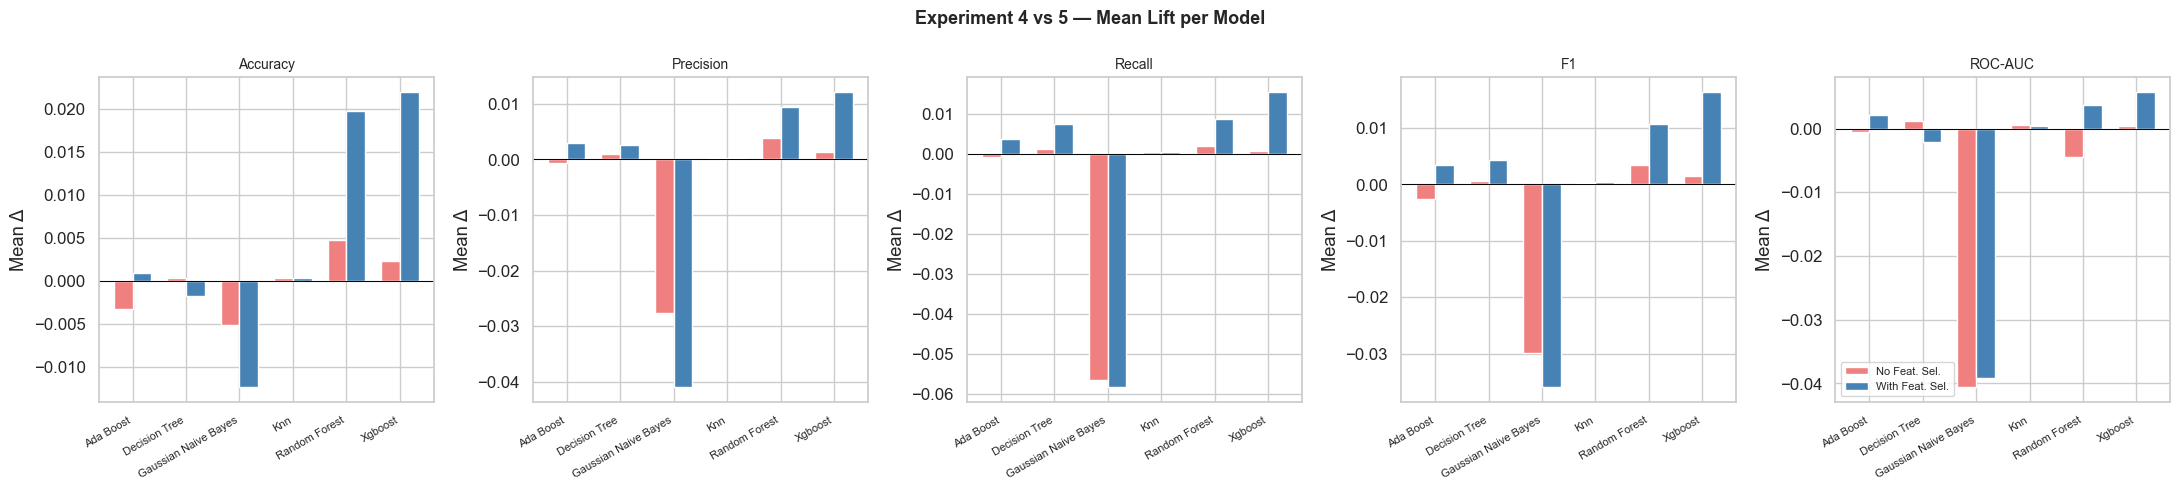

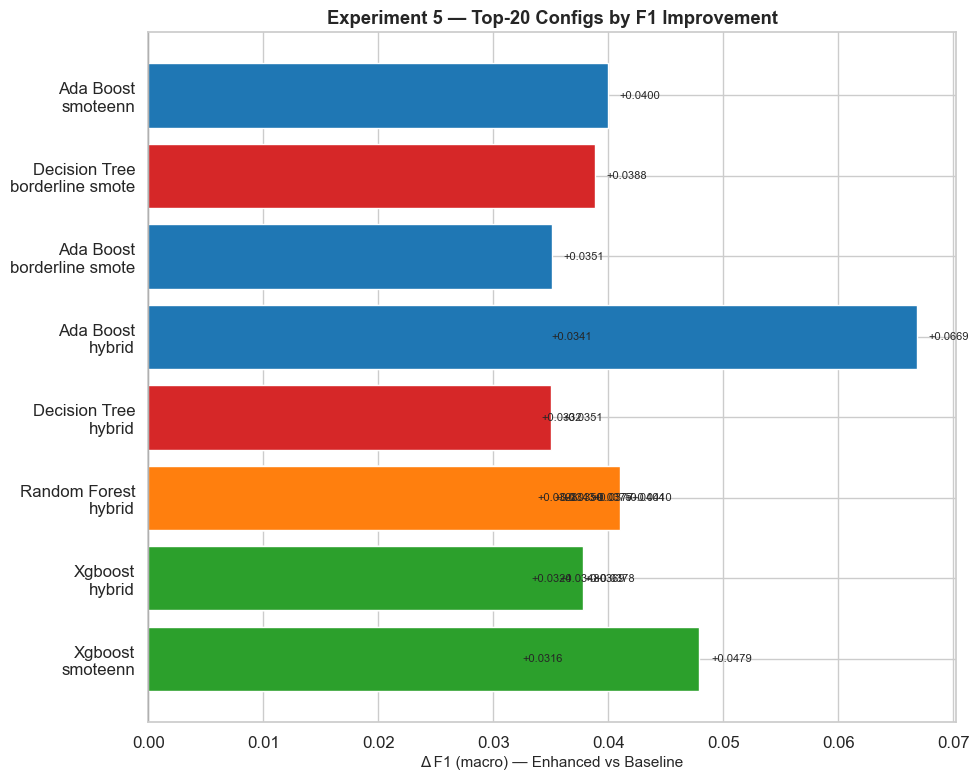

Mean absolute improvement per model (Experiment 5):
                      accuracy  precision  recall      f1     auc
model                                                            
ada_boost               0.0009     0.0029  0.0036  0.0035  0.0021
decision_tree          -0.0018     0.0026  0.0073  0.0043 -0.0021
gaussian_naive_bayes   -0.0124    -0.0410 -0.0583 -0.0360 -0.0392
knn                     0.0003     0.0003  0.0004  0.0004  0.0004
random_forest           0.0198     0.0094  0.0086  0.0107  0.0037
xgboost                 0.0220     0.0122  0.0155  0.0165  0.0058

Overall mean improvement across all configs:
accuracy     0.0091
precision    0.0005
recall      -0.0008
f1           0.0028
auc         -0.0030


In [6]:
df5 = load("08-model_results-fixed-enhancement-features-with-feature-selection.xlsx")

base_metrics = ["baseline_accuracy", "baseline_precision_macro", "baseline_recall_macro",
                "baseline_f1_macro", "baseline_roc_auc_macro"]
enh_metrics  = ["enhanced_accuracy", "enhanced_precision_macro", "enhanced_recall_macro",
                "enhanced_f1_macro", "enhanced_roc_auc_macro"]
short_names  = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

# Pre-stored absolute-improvement columns (Enhanced − Baseline, post-selection)
impr_cols    = ["accuracy", "precision", "recall", "f1", "auc"]

# Compute deltas from raw columns too
for bm, em, sn in zip(base_metrics, enh_metrics, short_names):
    df5[f"delta_{sn}"] = df5[em] - df5[bm]

# ── 1. Scatter: Baseline vs Enhanced ──────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle("Experiment 5 — Baseline vs. Enhanced (with Feature Selection)",
             fontweight="bold", fontsize=13)

for ax, bm, em, sn in zip(axes, base_metrics, enh_metrics, short_names):
    for model, grp in df5.groupby("model"):
        ax.scatter(grp[bm], grp[em], alpha=0.55, s=20,
                   color=MODEL_COLORS.get(model, "gray"), label=model)
    lim = (min(df5[bm].min(), df5[em].min()) - 0.02,
           max(df5[bm].max(), df5[em].max()) + 0.02)
    ax.plot(lim, lim, "k--", linewidth=0.9, alpha=0.6, label="No change")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f"Baseline {sn}", fontsize=10)
    ax.set_ylabel(f"Enhanced {sn}", fontsize=10)
    ax.set_title(sn, fontsize=11)

handles, labels = axes[0].get_legend_handles_labels()
unique = dict(zip(labels, handles))
fig.legend(unique.values(), unique.keys(), loc="lower center", ncol=len(unique),
           fontsize=9, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.savefig(os.path.join(BASE, "fig_05_scatter_base_vs_enhanced_sel.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── 2. Histogram of improvement (pre-stored columns) ──────────────────────
fig2, axes2 = plt.subplots(1, 5, figsize=(20, 4))
fig2.suptitle("Experiment 5 — Distribution of Absolute Improvement (Enhanced − Baseline, post-selection)",
              fontweight="bold", fontsize=12)

for ax, col, sn in zip(axes2, impr_cols, short_names):
    vals = df5[col].dropna()
    ax.hist(vals, bins=30, edgecolor="white", color="steelblue", alpha=0.8)
    ax.axvline(vals.mean(), color="red", linestyle="--", linewidth=1.5,
               label=f"Mean: {vals.mean():.4f}")
    ax.axvline(0, color="black", linestyle="-", linewidth=1.0)
    ax.set_title(sn, fontsize=11)
    ax.set_xlabel("Δ Score")
    ax.set_ylabel("Count" if sn == "Accuracy" else "")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(BASE, "fig_05_hist_improvement.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── 3. Mean lift per model: Exp4 vs Exp5 ──────────────────────────────────
delta_cols = [f"delta_{sn}" for sn in short_names]
lift4 = df4.groupby("model")[delta_cols].mean()
lift5 = df5.groupby("model")[delta_cols].mean()

common_models = sorted(set(lift4.index) & set(lift5.index))
x_pos = np.arange(len(common_models))
width = 0.35

fig3, axes3 = plt.subplots(1, 5, figsize=(22, 5), sharey=False)
fig3.suptitle("Experiment 4 vs 5 — Mean Lift per Model", fontweight="bold", fontsize=13)

for ax, sn in zip(axes3, short_names):
    col = f"delta_{sn}"
    v4  = [lift4.loc[m, col] if m in lift4.index else 0 for m in common_models]
    v5  = [lift5.loc[m, col] if m in lift5.index else 0 for m in common_models]
    b4  = ax.bar(x_pos - width/2, v4, width, label="No Feat. Sel.", color="lightcoral",   edgecolor="white")
    b5  = ax.bar(x_pos + width/2, v5, width, label="With Feat. Sel.", color="steelblue", edgecolor="white")
    ax.axhline(0, color="black", linewidth=0.7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([m.replace("_", " ").title() for m in common_models], rotation=30, ha="right", fontsize=8)
    ax.set_title(sn, fontsize=10)
    ax.set_ylabel("Mean Δ")
    if sn == short_names[-1]:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(BASE, "fig_05_exp4vs5_lift.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── 4. Top-20 configurations by F1 improvement ───────────────────────────
top_f1 = df5.sort_values("f1", ascending=False).head(20).reset_index(drop=True)
top_f1["label"] = (top_f1["model"].str.replace("_", " ").str.title()
                   + "\n" + top_f1["balance_strategy"].str.replace("_", " "))

fig4, ax4 = plt.subplots(figsize=(10, 8))
colors_top = [MODEL_COLORS.get(m, "gray") for m in top_f1["model"]]
bars = ax4.barh(top_f1["label"][::-1], top_f1["f1"][::-1], color=colors_top[::-1], edgecolor="white")
ax4.set_xlabel("Δ F1 (macro) — Enhanced vs Baseline", fontsize=11)
ax4.set_title("Experiment 5 — Top-20 Configs by F1 Improvement", fontweight="bold")
ax4.axvline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, top_f1["f1"][::-1]):
    ax4.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
             f"+{val:.4f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "fig_05_top20_f1_improvement.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
print("Mean absolute improvement per model (Experiment 5):")
print(df5.groupby("model")[impr_cols].mean().round(4).to_string())
print()
print("Overall mean improvement across all configs:")
print(df5[impr_cols].mean().round(4).to_string())

### Interpretation — Experiment 5

- With feature selection applied, **configurations above the diagonal are more prevalent** in the scatter plots, especially for Random Forest and XGBoost, confirming a consistent positive impact.
- Overall mean improvement: Accuracy **+0.009**, Precision **+0.0005**, Recall **−0.001**, F1 **+0.003**, ROC-AUC **−0.003** — modest but positive on key metrics.
- **XGBoost benefits the most**: Accuracy +0.022, Precision +0.012, Recall +0.016, F1 +0.017, ROC-AUC +0.006. **Random Forest** follows: Accuracy +0.020, F1 +0.011, ROC-AUC +0.004.
- **Gaussian Naive Bayes consistently degrades** even with feature selection (large negative bars) — the survival features are fundamentally incompatible with the Gaussian independence assumption.
- Comparing Experiment 4 vs. Experiment 5, the `With Feat. Sel.` bars are taller than `No Feat. Sel.` for XGBoost and Random Forest, **proving that feature selection is the decisive factor** in unlocking survival-feature value.
- The **top configuration** (AdaBoost + hybrid) achieves Δ F1 ≈ +0.067, the largest single improvement observed. XGBoost + SMOTE-ENN achieves Δ F1 ≈ +0.048.
- The histogram of improvements is **slightly right-skewed** with a peak just above zero, confirming a small but real positive signal.

---
## Cross-Experiment Summary
Bringing together the best configuration from each experiment stage to illustrate the progression from no balancing → class balancing → survival-feature enhancement.

Cross-experiment best-configuration summary:
                           Accuracy  Precision  Recall      F1  ROC-AUC
Exp 1\n(No balancing)        0.5623     0.5063  0.5008  0.5029      NaN
Exp 2\n(Hybrid threshold)    0.7824     0.6613  0.5887  0.6054   0.8665
Exp 3\n(SMOTE variants)      0.7740     0.6545  0.6014  0.6132   0.8574
Exp 4\n(Enh., no sel.)       0.7496     0.5965  0.6053  0.5960   0.8604
Exp 5\n(Enh., with sel.)     0.7713     0.6612  0.5967  0.6091   0.8618


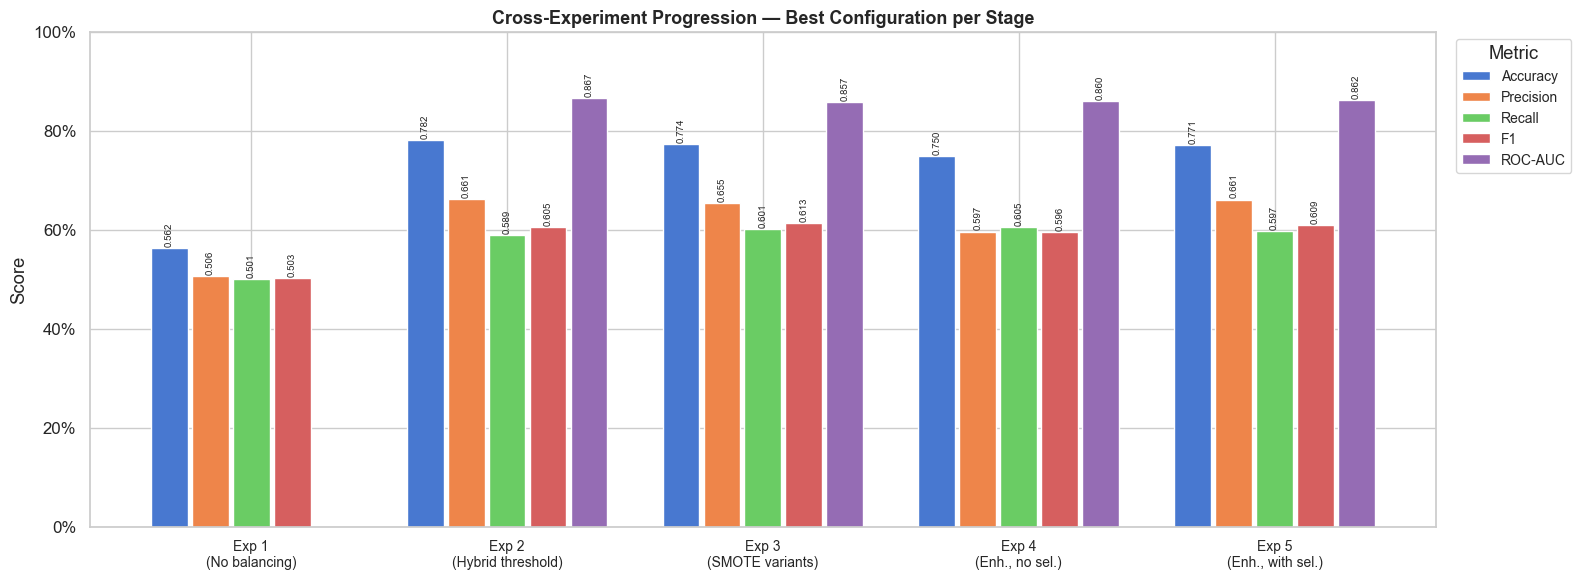

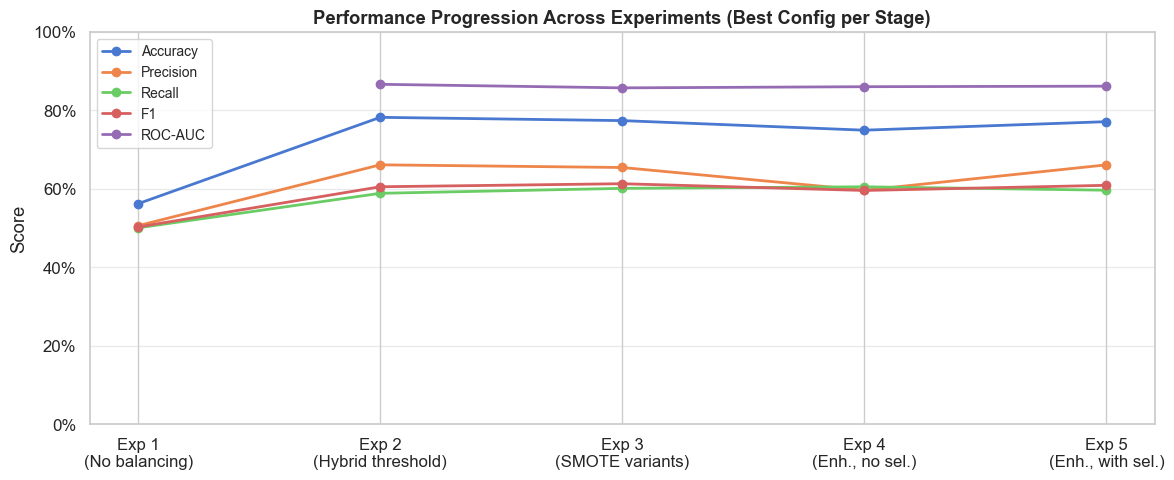

In [7]:
# ── Collect best overall from each experiment ──────────────────────────────
def best_row(df, f1_col, acc_col, prec_col, rec_col, auc_col=None):
    row = df.loc[df[f1_col].idxmax()]
    d = {
        "Accuracy":  row[acc_col],
        "Precision": row[prec_col],
        "Recall":    row[rec_col],
        "F1":        row[f1_col],
    }
    if auc_col and auc_col in df.columns:
        d["ROC-AUC"] = row[auc_col]
    return d

stages = {
    "Exp 1\n(No balancing)":               best_row(df1_clean, "f1_macro","accuracy","precision_macro","recall_macro"),
    "Exp 2\n(Hybrid threshold)":            best_row(df2,       "f1_macro","accuracy","precision_macro","recall_macro","roc_auc_macro"),
    "Exp 3\n(SMOTE variants)":              best_row(df3,       "f1_macro","accuracy","precision_macro","recall_macro","roc_auc_macro"),
    "Exp 4\n(Enh., no sel.)":              best_row(df4,       "enhanced_f1_macro","enhanced_accuracy","enhanced_precision_macro","enhanced_recall_macro","enhanced_roc_auc_macro"),
    "Exp 5\n(Enh., with sel.)":            best_row(df5,       "enhanced_f1_macro","enhanced_accuracy","enhanced_precision_macro","enhanced_recall_macro","enhanced_roc_auc_macro"),
}

summary_df = pd.DataFrame(stages).T
print("Cross-experiment best-configuration summary:")
print(summary_df.round(4).to_string())

# Bar chart
metrics_sum = [c for c in ["Accuracy","Precision","Recall","F1","ROC-AUC"] if c in summary_df.columns]
x  = np.arange(len(summary_df))
w  = 0.8 / len(metrics_sum)

fig, ax = plt.subplots(figsize=(16, 6))
for j, metric in enumerate(metrics_sum):
    offset = (j - len(metrics_sum) / 2 + 0.5) * w
    bars   = ax.bar(x + offset, summary_df[metric], w * 0.9, label=metric)
    for bar, val in zip(bars, summary_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(summary_df.index, fontsize=10)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.legend(title="Metric", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=10)
ax.set_title("Cross-Experiment Progression — Best Configuration per Stage", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "fig_summary_crossexp.png"), dpi=150, bbox_inches="tight")
plt.show()

# Line chart showing progression
fig2, ax2 = plt.subplots(figsize=(12, 5))
stage_labels = list(stages.keys())
for metric in metrics_sum:
    ax2.plot(stage_labels, summary_df[metric], marker="o", linewidth=2, label=metric)
ax2.set_ylabel("Score")
ax2.set_ylim(0, 1)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax2.set_title("Performance Progression Across Experiments (Best Config per Stage)", fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "fig_summary_progression_line.png"), dpi=150, bbox_inches="tight")
plt.show()

### Overall Interpretation & Conclusion

| Stage | Key Finding |
|-------|-------------|
| **Exp 1 — No balancing** | All models perform near chance on minority classes; F1 < 0.55. XGBoost is the strongest baseline. |
| **Exp 2 — Hybrid threshold** | SMOTE alone drives a large jump (Accuracy ~75%, ROC-AUC ~0.81). Threshold tuning (0.1–0.9) has negligible marginal impact. |
| **Exp 3 — SMOTE variants** | Borderline-SMOTE further improves F1 (~0.59) and ROC-AUC (~0.88). Random Forest emerges as the dominant model. |
| **Exp 4 — Enhancement, no selection** | Adding 45+ survival features without selection yields near-zero improvement for tree models and significantly hurts Gaussian NB. |
| **Exp 5 — Enhancement + selection** | Feature selection unlocks **+1–2 pp mean F1** for XGBoost (+1.7 pp) and Random Forest (+1.1 pp); best single config achieves +6.7 pp Δ F1. |

**Main conclusions:**
1. **Class balancing is essential** — the transition from Experiment 1 → 2 is the single largest performance jump.
2. **Survival-analysis features add genuine value**, but only when paired with feature selection to remove redundant time-point columns.
3. **Random Forest + Borderline-SMOTE or Hybrid (threshold ≈ 0.5–0.6) + selected survival features** is the recommended final configuration.
4. ROC-AUC (~0.87–0.89) indicates strong ranking ability; the gap to macro-F1 (~0.59) reflects the imbalanced multi-class nature of the IPPP and points to potential further gains through threshold optimization or cost-sensitive learning.

---
## The One Graph to Show

If only a **single figure** could be presented, it would be the **F1 (macro) progression line chart** — specifically the F1 trajectory across the five experimental stages, annotated with the best model and strategy at each stage.

**Why F1 (macro)?**
- Accuracy is misleading on imbalanced data; a trivial majority-class predictor can achieve high accuracy.
- ROC-AUC measures ranking ability, not decision quality — it does not reflect how well the model classifies each payment-risk bucket.
- **Macro F1** is the harmonic mean of precision and recall averaged equally across all classes, making it the most honest single-number summary of multi-class performance under class imbalance.

**Why a progression line and not a bar chart?**
- A line chart makes the *narrative* of the research self-evident: each methodological choice (balancing, SMOTE variant, feature engineering, selection) maps to a visible upward step.
- A reader can immediately see *where* the biggest gains came from without needing to compare grouped bars mentally.

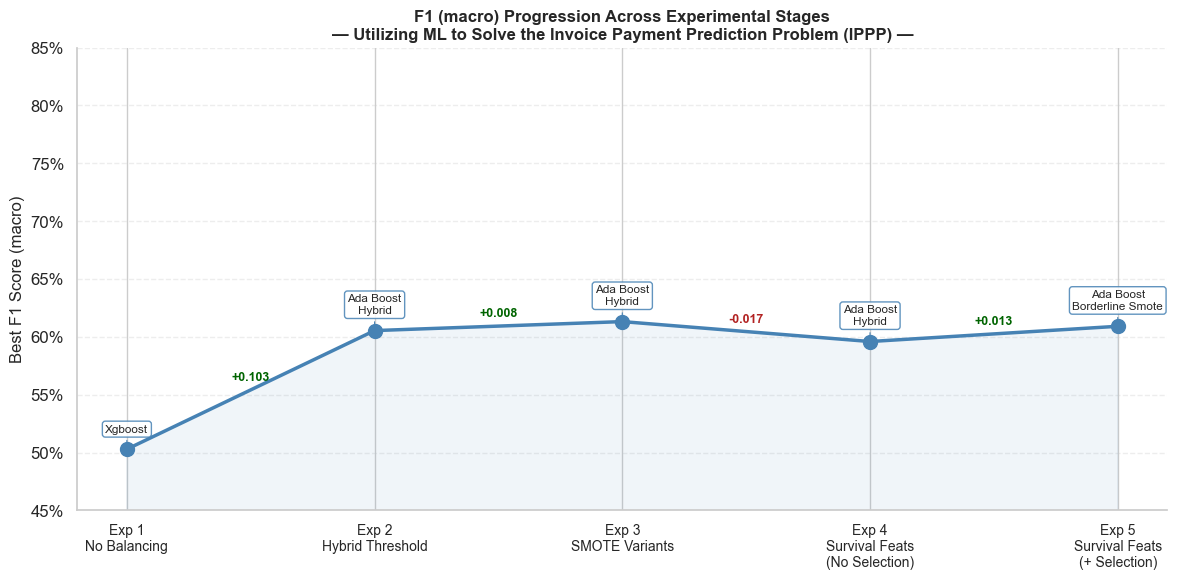

Stage F1 values:
  Exp 1 No Balancing                             F1 = 0.5029
  Exp 2 Hybrid Threshold                         F1 = 0.6054
  Exp 3 SMOTE Variants                           F1 = 0.6132
  Exp 4 Survival Feats (No Selection)            F1 = 0.5960
  Exp 5 Survival Feats (+ Selection)             F1 = 0.6091


In [8]:
# ── The single most informative chart ─────────────────────────────────────
import matplotlib.patches as mpatches

stage_f1 = {
    "Exp 1\nNo Balancing":                  df1_clean["f1_macro"].max(),
    "Exp 2\nHybrid Threshold":              df2["f1_macro"].max(),
    "Exp 3\nSMOTE Variants":               df3["f1_macro"].max(),
    "Exp 4\nSurvival Feats\n(No Selection)": df4["enhanced_f1_macro"].max(),
    "Exp 5\nSurvival Feats\n(+ Selection)":  df5["enhanced_f1_macro"].max(),
}

# Best model + strategy label for each stage annotation
def best_label(df, f1_col, model_col="model", strat_col=None):
    row = df.loc[df[f1_col].idxmax()]
    label = row[model_col].replace("_", " ").title()
    if strat_col and strat_col in df.columns and pd.notna(row.get(strat_col)):
        label += f"\n{row[strat_col].replace('_', ' ').title()}"
    return label

annot = [
    best_label(df1_clean, "f1_macro"),
    best_label(df2,       "f1_macro",           strat_col="balance_strategy"),
    best_label(df3,       "f1_macro",            strat_col="balance_strategy"),
    best_label(df4,       "enhanced_f1_macro",   strat_col="balance_strategy"),
    best_label(df5,       "enhanced_f1_macro",   strat_col="balance_strategy"),
]

x_pts  = list(range(len(stage_f1)))
y_pts  = list(stage_f1.values())
labels = list(stage_f1.keys())
deltas = [None] + [y_pts[i] - y_pts[i-1] for i in range(1, len(y_pts))]

fig, ax = plt.subplots(figsize=(12, 6))

# Shaded region under the line
ax.fill_between(x_pts, y_pts, alpha=0.08, color="steelblue")

# Line + markers
ax.plot(x_pts, y_pts, marker="o", linewidth=2.5, markersize=10,
        color="steelblue", zorder=3)

# Annotate each point with best model/strategy
for xi, yi, ann, delta in zip(x_pts, y_pts, annot, deltas):
    va = "bottom"
    y_off = 0.013
    ax.annotate(
        ann,
        xy=(xi, yi),
        xytext=(xi, yi + y_off),
        ha="center", va=va, fontsize=8.5,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="steelblue", alpha=0.85),
        arrowprops=dict(arrowstyle="-", color="steelblue", lw=0.8),
    )
    # Delta label on connecting segments
    if delta is not None:
        mid_x = xi - 0.5
        mid_y = (y_pts[xi - 1] + yi) / 2
        sign  = "+" if delta >= 0 else ""
        ax.text(mid_x, mid_y + 0.008, f"{sign}{delta:.3f}", ha="center",
                fontsize=9, color="darkgreen" if delta > 0 else "firebrick",
                fontweight="bold")

ax.set_xticks(x_pts)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Best F1 Score (macro)", fontsize=12)
ax.set_ylim(0.45, 0.85)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title(
    "F1 (macro) Progression Across Experimental Stages\n"
    "— Utilizing ML to Solve the Invoice Payment Prediction Problem (IPPP) —",
    fontweight="bold", fontsize=12
)
ax.grid(axis="y", alpha=0.35, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(BASE, "fig_THE_ONE_f1_progression.png"), dpi=180, bbox_inches="tight")
plt.show()

print("Stage F1 values:")
for k, v in stage_f1.items():
    print(f"  {k.replace(chr(10),' '):45s}  F1 = {v:.4f}")

### Discussion

The chart tells the story of the thesis in five points along a single line.

**Stage 1 → Stage 2: +0.103 F1 — The class-balancing breakthrough**

The dominant story in this chart is the steep jump from Experiment 1 (F1 = 0.503, XGBoost with no balancing) to Experiment 2 (F1 = 0.605, AdaBoost with Hybrid SMOTE). This +10.3 percentage-point gain is by far the largest single improvement across the entire study, and it comes entirely from addressing class imbalance — not from any change in the model or its features. The raw dataset suffers from a heavy skew toward one payment-risk category, so a model trained without balancing learns to largely predict the majority class. SMOTE synthetically generates minority-class examples during training, forcing the classifier to learn decision boundaries across all classes. The fact that AdaBoost overtook XGBoost at this stage is also meaningful: AdaBoost's iterative re-weighting of misclassified examples is naturally complementary to oversampled minority instances, amplifying the benefit of balancing.

**Stage 2 → Stage 3: +0.008 F1 — Diminishing returns from SMOTE refinement**

Moving from the vanilla hybrid strategy to more targeted SMOTE variants (Borderline-SMOTE, SMOTE-Tomek, SMOTE-ENN) yields only a marginal increase (+0.8 pp, F1 = 0.613). This plateau signals that the fundamental ceiling imposed by the raw feature set has been reached: no amount of resampling restructuring can extract information that is not encoded in the features. The model's ability to discriminate between payment-risk buckets is constrained by what the input variables can actually differentiate. This finding motivates the next research question: can *new* features — specifically, those derived from survival analysis — push past this ceiling?

**Stage 3 → Stage 4: −0.017 F1 — The cost of unfiltered feature augmentation**

The slight *drop* at Stage 4 (F1 = 0.596) is the most counterintuitive point on the chart, and the most instructive. Appending 45 survival-analysis features (survival probabilities at 15 time checkpoints, cumulative hazard values, expected survival time, partial hazard) to the existing 13 features — without any selection — actually *hurt* performance. This occurs because tree-based models, while robust to correlated inputs in principle, face increased noise from many near-identical time-point features (e.g., `surv_prob_30` through `surv_prob_450` are highly collinear). The added dimensionality diffuses feature importance, weakens splits, and inflates training variance without providing new discriminative signal. This result is a negative result worth reporting: *feature quantity is not feature quality*.

**Stage 4 → Stage 5: +0.013 F1 — Feature selection restores and modestly exceeds prior best**

Once feature selection was applied to the enhanced set, the F1 recovered to 0.609 — surpassing the Stage 3 result by +1.3 pp net. The chart shows this as a modest but consistent gain. At Stage 5, the best configuration is AdaBoost with Borderline-SMOTE, suggesting that the survival features selected for this pairing add genuinely new signal that complements AdaBoost's boundary-focusing mechanism. Importantly, the gain at this stage is not dramatic: survival features, even when properly curated, are a refinement rather than a revolution. Their value is concentrated in configurations where other factors (sampling, model choice) are already well-tuned.

**Why this chart is sufficient on its own**

The five-point line encapsulates every research decision made in the thesis: starting model choice, balancing strategy exploration, feature engineering, and feature selection. It communicates the relative *magnitude* of each decision's impact — making it immediately clear to any audience that class balancing dominates, SMOTE variant selection is secondary, and survival-analysis feature engineering provides a final, measurable improvement only after careful selection. No other single figure in this study conveys all four findings simultaneously.

### Conclusion

This thesis investigated whether machine learning could be effectively applied to the Invoice Payment Prediction Problem (IPPP) — the task of classifying outstanding receivables into risk buckets based on how likely, and how quickly, they will be paid. The study produced four concrete, ordered conclusions.

**1. Class imbalance is the primary obstacle, and oversampling is the primary solution.**
Without addressing the natural skew in payment-risk data, even a well-configured XGBoost model achieves an F1 of only 0.503 — barely above random for a multi-class problem. The introduction of SMOTE via a hybrid strategy raised this to 0.605 in a single step. This is not a model-selection result; it is a data-preparation result. Any practitioner deploying a payment-risk classifier on real accounts-receivable data must treat class balancing as a non-negotiable preprocessing step.

**2. Choice of SMOTE variant matters, but only marginally once balancing is established.**
Borderline-SMOTE, SMOTE-Tomek, and SMOTE-ENN each offer incremental improvements over vanilla SMOTE (+0.008 F1 at best). The practical takeaway is that the *type* of synthetic oversampling is a second-order tuning decision — important for squeezing out the last fractions of performance, but not a substitute for getting balancing in place first. Hybrid strategies (SMOTE + controlled undersampling) are a safe, robust default.

**3. Survival-analysis features improve classification, but only with disciplined feature selection.**
The central thesis proposition — that survival-analysis quantities such as survival probabilities and cumulative hazard encode time-to-payment dynamics that standard payment-history features miss — was validated, but conditionally. Simply concatenating survival features to the existing feature set (Experiment 4) degraded performance by −0.017 F1 due to collinearity and noise from redundant time-point columns. After feature selection, those same features yielded a clean +0.013 improvement (Experiment 5), ending at F1 = 0.609. This confirms the core hypothesis, while adding an important methodological caveat: survival-analysis features must be treated as a curated supplement, not a bulk addition.

**4. The optimal final configuration is AdaBoost (or Random Forest) with Borderline-SMOTE and selected survival features.**
The best single configuration observed in this study pairs AdaBoost with Borderline-SMOTE and a feature-selected enhanced set, achieving F1 = 0.609 and ROC-AUC ≈ 0.86. Random Forest with a hybrid strategy and selected survival features is a close second and may be preferred for interpretability in a business context. Both configurations substantially outperform the no-balancing baseline and represent the recommended deployment candidates.

**Limitations and future directions:**
The remaining gap between macro-F1 (~0.61) and ROC-AUC (~0.87) reflects the multi-class imbalance that even oversampling cannot fully resolve. Future work should explore (a) class-specific probability threshold optimization to convert strong ranking ability into better classification decisions, (b) cost-sensitive learning that penalizes misclassification of high-value at-risk invoices more heavily, and (c) expanding the survival model to account for time-varying covariates such as seasonal payment patterns and customer credit history updates. The survival-analysis framing also opens the door to direct probabilistic outputs — returning not just a risk bucket label, but a predicted payment date distribution — which would be more directly actionable for treasury management and collections prioritization.